**Case Study: ReadyNow! Federal Emergency Machine Assistant**

**Goal: Demonstrate your ability to build a complex multi-agent system using the Google ADK**

Requirements:

* A root agent that describes what the agent can do and coordinates tasks and sub-agents

* Agents for weather forecasting, searching the internet, providing routes using the Google
Maps API, and answering questions

* A sequential workflow that validates and refines responses from the agent

* Callbacks functions to log all user-agent interactions

* User input validation

* Deploy the agent to Agent Platform

* Test code that demonstrate the agent’s functionality

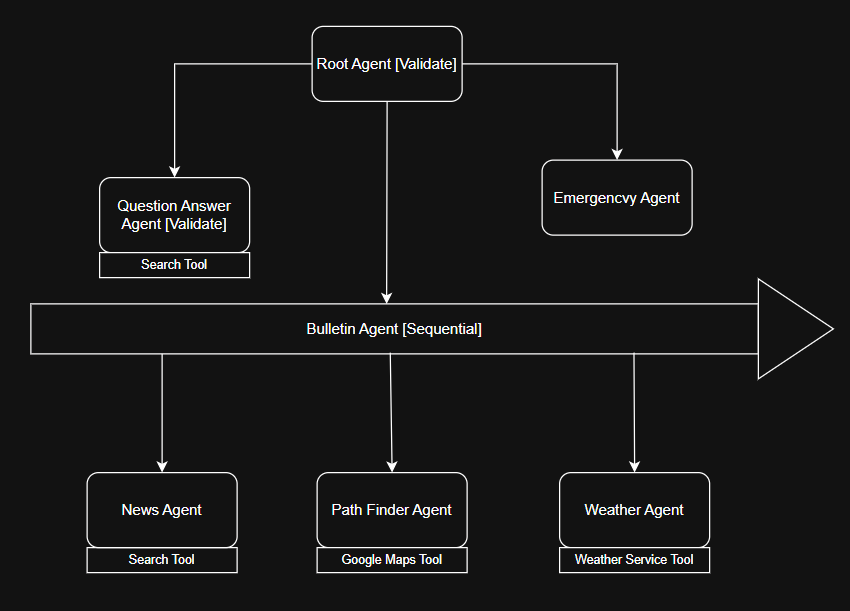

In [1]:
# @title Setup, Installation, and api key management

# Install ADK and LiteLLM
!pip install google-adk -q
!pip install litellm -q
!pip install google-cloud-aiplatform -q
#!pip install ipython
#!pip install "google-adk[web]" -q

print("Installation complete.")

Installation complete.


In [2]:
# @title Imports, Settings and Constants
from google.adk.agents import Agent, LlmAgent, LoopAgent, SequentialAgent
from google.adk.models import LlmResponse, LlmRequest
from google.adk.agents.callback_context import CallbackContext
from google.adk.sessions import InMemorySessionService
from google.adk.runners import Runner
from google.genai import types # For creating message Content/Parts
from google.adk.tools import google_maps_grounding
from google.adk.tools.tool_context import ToolContext
from typing import Optional, Dict, Any
from google.adk.tools.base_tool import BaseTool
from google.adk.tools import google_search, agent_tool, tool_context
import logging
import textwrap

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# More supported models can be referenced here: https://ai.google.dev/gemini-api/docs/models#model-variations
MODEL_GEMINI_2_5_FLASH = "gemini-2.5-flash"
GOOGLE_MAPS_API_KEY = "<insert your api key>"

print("\nEnvironment configured.")



Environment configured.


/usr/local/lib/python3.12/dist-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature FeatureName.PLUGGABLE_AUTH is enabled.
  check_feature_enabled()


In [3]:
# @title log_user_prompt

def log_user_prompt(callback_context: CallbackContext, llm_request: LlmRequest) -> Optional[LlmResponse]:
    """Logs the user prompts."""

    agent_name = callback_context.agent_name
    log_header = f"[Callback:{agent_name}:log_user_prompt]"

    # Inspect the last user message in the request contents
    last_user_message = ""
    if llm_request.contents and llm_request.contents[-1].role == 'user':
         if llm_request.contents[-1].parts:
            last_user_message = llm_request.contents[-1].parts[0].text

    if last_user_message == None or last_user_message == "":
        return None

    logging.info(f"{log_header} Logging last user message: '{last_user_message}'")
    print(f"{log_header} Logging last user message: '{last_user_message}'")

    return None


In [4]:
# @title log_model_response

def log_model_response(
    callback_context: CallbackContext, llm_response: LlmResponse
) -> Optional[LlmResponse]:
    """Logs the model's responses."""

    agent_name = callback_context.agent_name
    log_header = f"[Callback:{agent_name}:log_model_response]"

    # --- Inspection ---
    original_text = ""
    if llm_response.content and llm_response.content.parts:
        # Assuming simple text response for this example
        if llm_response.content.parts[0].text:
            original_text = llm_response.content.parts[0].text
            logging.info(f"{log_header} Inspected original response text: '{original_text[:100]}...'") # Log snippet
            print(f"{log_header} Inspected original response text: '{original_text[:100]}...'")
        elif llm_response.content.parts[0].function_call:
             logging.info(f"{log_header} Inspected response: Contains function call '{llm_response.content.parts[0].function_call.name}'. No text modification.")
             print(f"{log_header} Inspected response: Contains function call '{llm_response.content.parts[0].function_call.name}'. No text modification.")
             return None # Don't modify tool calls in this example
        else:
             logging.info(f"{log_header} Inspected response: No text content found.")
             print(f"{log_header} Inspected response: No text content found.")
             return None
    elif llm_response.error_message:
        logging.info(f"{log_header} Inspected response: Contains error '{llm_response.error_message}'. No modification.")
        print(f"{log_header} Inspected response: Contains error '{llm_response.error_message}'. No modification.")
        return None
    else:
        logging.info(f"{log_header} Inspected response: Empty LlmResponse.")
        print(f"{log_header} Inspected response: Empty LlmResponse.")
        return None # Nothing to modify

    return None

In [5]:
# @title append_to_bulletin, read_bulletin
def append_to_bulletin(tool_context, response):
  """
  USE THIS TO APPEND A RESPONSE TO THE BULLETIN

  Args:
    tool_context: The tool context object.
    response: The response to append.

  Returns:
    dict: A status message indicating the success of the operation.
  """
  existing_state = tool_context.state.get("bulletin", [])
  tool_context.state["bulletin"] = existing_state + [response + "\n"]
  return {"status": "success"}


def read_bulletin(tool_context):
  """
  USE THIS TO READ ALL THE ACCUMULATED RESPONSES IN THE BULLETIN

  Args:
    tool_context: The tool context object.

  Returns:
    list: A list of strings containing the bulletin entries.
  """
  return tool_context.state.get("bulletin", [])

print("read_bulletin tool defined.")

read_bulletin tool defined.


In [6]:
# @title is_simulation, set_simulation

def is_simulation(tool_context):
  """
  USE THIS TO DETERMINE IF THE EMERGENCIES ARE SIMULATION OR REAL

  Args:
    tool_context: The tool context object.

  Returns:
    bool: Indicates if this is a simmulation.
  """
  content = tool_context.state.get("is_emergency_simulation")
  if content is None:
    return False
  return (content == True)


def set_simulation_status(tool_context, value: bool):
  """
  USE THIS TO SET THE STATUS TO SIMMULATION

  Args:
    tool_context: The tool context object.
    value: The boolean indicating true if it is a simmulation and not reality

  Returns:
    dict: A status message indicating the success of the operation.
  """
  if value is None:
    tool_context.state["is_emergency_simulation"] = True
  else:
    tool_context.state["is_emergency_simulation"] = value

  return {"status": "success", "message": "Emergency event updated."}


In [7]:
# @title read_emergency_event, add_emergency_event

def read_emergency_event(tool_context):
  """
  USE THIS TO READ AN ONGOING EMERGENCY EVENT
  Returns the event information

  Args:
    tool_context: The tool context object.

  Returns:
    dict: A dictionary describing the emergency event.
                  Expected format:
                  {
                      "epicenter_lat": float,  # Latitude of the event epicenter
                      "epicenter_lon": float,  # Longitude of the event epicenter
                      "affected_radius_miles": float, # Radius of the affected area in miles
                      "projected_epicenter_30min": { # Projected epicenter in 30 minutes
                          "lat": float,
                          "lon": float
                      },
                      "description": str # A brief description of the event
                  }
  """
  content = tool_context.state.get("emergency_event")
  if content is None:
    return "There are no emergency events being tracked."
  return content


def add_emergency_event(tool_context, value):
  """
  USE THIS TO ADD AN EMERGENCY EVENT
  Provide the event information in the value parameter.

  Args:
    tool_context: The tool context object.
    value (dict): A dictionary describing the emergency event.
                  Expected format:
                  {
                      "epicenter_lat": float,  # Latitude of the event epicenter
                      "epicenter_lon": float,  # Longitude of the event epicenter
                      "affected_radius_miles": float, # Radius of the affected area in miles
                      "projected_epicenter_30min": { # Projected epicenter in 30 minutes
                          "lat": float,
                          "lon": float
                      },
                      "description": str # A brief description of the event
                  }
  Returns:
    dict: A status message indicating the success of the operation.
  """
  tool_context.state["emergency_event"] = value
  return {"status": "success", "message": "Emergency event updated."}


In [8]:
# @title get_user_location, set_user_location

def get_user_location(tool_context):
  """
  USE THIS TO READ THE USER'S LOCATION USING LATITUDE, LONGITUDE
  Return a json object in the form, { "latitude": "", "longitude": "" }

  Args:
    tool_context: The tool context object.

  Returns:
    value (dict): A dictionary describing the user's location.
                  Expected format:
                  {
                    "lat": float,  # Latitude of the user
                    "lon": float,  # Longitude of the user
                  }
  """
  content = tool_context.state.get("user_location")
  if content is None:
    return "There are no emergency events being tracked."
  return content


def set_user_location(tool_context, value):
  """
  USE THIS TO SET THE USER'S LOCATION USING LATITUDE, LONGITUDE
  Expect the value to have Latitude and Longitude values. Save the
  valus in a json object of the form, { "latitude": "", "longitude": "" }.

  Args:
    tool_context: The tool context object.
    value (dict): A dictionary describing the user's location.
                  Expected format:
                  {
                    "lat": float,  # Latitude of the user
                    "lon": float,  # Longitude of the user
                  }

  Returns:
    dict: A status message indicating the success of the operation.
  """
  tool_context.state["user_location"] = value
  return {"status": "success", "message": "Emergency event updated."}


In [9]:
# @title get_location_lat_long

import requests

def get_location_lat_long(city: str, state: str) -> dict[str, float | None]:
    """
    Use the Google Maps Geocoding API to convert a city and state into a location object.

    Args:
        city: The city name, such as "Knoxville".
        state: The state abbreviation or name, such as "TN" or "Tennessee".

    Returns:
        A dictionary containing the latitude and longitude.

        Example:
        {
            "Latitude": 35.9606384,
            "Longitude": -83.9207392
        }

        If the location cannot be found or the API request fails, both values will be None:

        {
            "Latitude": None,
            "Longitude": None
        }
    """

    address = f"{city}, {state}"

    url = "https://maps.googleapis.com/maps/api/geocode/json"
    params = {
        "address": address,
        "key": GOOGLE_MAPS_API_KEY
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        print(f"Geocoding API error: {response.status_code}")
        return {
            "Latitude": None,
            "Longitude": None
        }

    data = response.json()

    if data.get("status") != "OK" or not data.get("results"):
        print(f"Geocoding API returned no results: {data.get('status')}")
        return {
            "Latitude": None,
            "Longitude": None
        }

    location = data["results"][0]["geometry"]["location"]

    return {
        "Latitude": location["lat"],
        "Longitude": location["lng"]
    }


# test
result = get_location_lat_long("knoxville", "tn")
print(result)

{'Latitude': 35.965266, 'Longitude': -83.923304}


In [10]:
# @title get_nws_forecast
import requests

def get_nws_forecast(lat: float, lon: float) -> str:
    """
    Fetches the weather forecast from the National Weather Service (NWS) for a given location.

    Args:
        lat: Latitude of the location.
        lon: Longitude of the location.

    Returns:
        A string containing the weather forecast or an error message.
    """
    # NWS API requires a User-Agent header (can be any identifier)
    headers = {'User-Agent': '(my_colab_agent, contact@example.com)'}

    try:
        # Step 1: Get the forecast office and grid points for the coordinates
        points_url = f"https://api.weather.gov/points/{lat},{lon}"
        response = requests.get(points_url, headers=headers)
        response.raise_for_status()
        data = response.json()

        # Step 2: Get the forecast URL from the points data
        forecast_url = data['properties']['forecast']
        forecast_response = requests.get(forecast_url, headers=headers)
        forecast_response.raise_for_status()
        forecast_data = forecast_response.json()

        # Step 3: Parse the periods
        periods = forecast_data['properties']['periods']
        summary = ""
        for period in periods[:3]: # Get the next 3 forecast periods
            summary += f"{period['name']}: {period['detailedForecast']}\n"

        return summary
    except Exception as e:
        return f"Error fetching forecast from NWS: {str(e)}"

print("NWS tool defined.")

NWS tool defined.


In [11]:
# @title Define the Search Agent

AGENT_MODEL = MODEL_GEMINI_2_5_FLASH # Starting with Gemini

instruction = """
              You are a helpful search assistant.
              """

search_agent = Agent(
    name="search_agent",
    model=AGENT_MODEL, # Can be a string for Gemini or a LiteLlm object
    description="Provides generic search capabilities.",
    instruction=instruction,
    tools=[google_search],
    before_model_callback=log_user_prompt,
    after_model_callback=log_model_response
)

print(f"Agent '{search_agent.name}' created using model '{AGENT_MODEL}'.")

Agent 'search_agent' created using model 'gemini-2.5-flash'.


In [12]:
# @title Define the Emergency Event Agent

AGENT_MODEL = MODEL_GEMINI_2_5_FLASH # Starting with Gemini

instruction = """
              You have details about emergency events.
              Check to see if we are running a simmulation using the
              'is_simulation' tool. If it is true, add this emergency
              event using the 'add_emergency_event' tool including the latitude
              and longitude location of Nashville, TN using the '' tool.
              The value should be "There are sever lightning strikes occurring
              in the Nashville area. Seek shelter now. The storms will pass in 2 hours".
              If we are not in simmulation, use the search_agent to find
              the first weather alerts and warning in the united states.
              add the alert or warning to the 'add_emergency_event' tool.

              Always return to the 'root_agent' to continue.
              """

emergency_event_agent = Agent(
    name="emergency_event_agent",
    model=AGENT_MODEL, # Can be a string for Gemini or a LiteLlm object
    description="Provides details specific to an emergency event.",
    instruction=instruction,
    tools=[
        agent_tool.AgentTool(agent=search_agent),
        is_simulation,
        add_emergency_event,
        get_location_lat_long
        ],
    before_model_callback=log_user_prompt,
    after_model_callback=log_model_response
)

print(f"Agent '{emergency_event_agent.name}' created using model '{AGENT_MODEL}'.")

Agent 'emergency_event_agent' created using model 'gemini-2.5-flash'.


In [13]:
# @title Define the News Agent
AGENT_MODEL = MODEL_GEMINI_2_5_FLASH # Starting with Gemini

instruction = """
              You are a helpful agent that summarizes news outlets.
              You are looking for news about the current emergency event that
              is returned from the 'read_emergency_event' tool.
              If the event is a simmulation, 'is_simulation', just respond
              that, "There is no news on simmulated events. Don't Panic!". If it is
              a simmulation, you can respond with a summary and are done.
              Search the internet for news related to the emergency event. Summarize
              the News outlet information and provide a brief overview with any
              directions for how to respond to the event.

              Create a summary that starts with, "News: " and is short and easy to understand.
              Append your response using the 'append_to_bulletin' tool.
              """

news_agent = Agent(
    name="news_agent",
    model=AGENT_MODEL, # Can be a string for Gemini or a LiteLlm object
    description="Researches news outlets for a specific emergency event.",
    instruction=instruction,
    tools=[
        agent_tool.AgentTool(agent=search_agent),
        is_simulation,
        read_emergency_event,
        append_to_bulletin],
    before_model_callback=log_user_prompt,
    after_model_callback=log_model_response
)

print(f"Agent '{news_agent.name}' created using model '{AGENT_MODEL}'.")

Agent 'news_agent' created using model 'gemini-2.5-flash'.


In [14]:
# @title Define the Path Finder Agent
AGENT_MODEL = MODEL_GEMINI_2_5_FLASH # Starting with Gemini

instruction = """
              You are a helpful agent that cretes a fast path away from emergency events.
              Given the users' location, 'get_user_location', find the shortest route
              away from the emergency event. Use the 'read_emergency_event' tool to get
              the emergency event.
              Respond with a summary routhe the user should take in a responst
              that is short and easy to understand.

              Append your response starting with "PathFinder: " to the 'append_to_bulletin' tool.
              """

pathfinder_agent = Agent(
    name="pathfinder_agent",
    model=AGENT_MODEL, # Can be a string for Gemini or a LiteLlm object
    description="Researches the shortest routes away from the emergency event.",
    instruction=instruction,
    tools=[
        agent_tool.AgentTool(agent=search_agent),
        is_simulation,
        read_emergency_event,
        get_user_location,
        append_to_bulletin],
    before_model_callback=log_user_prompt,
    after_model_callback=log_model_response
)

print(f"Agent '{pathfinder_agent.name}' created using model '{AGENT_MODEL}'.")

Agent 'pathfinder_agent' created using model 'gemini-2.5-flash'.


In [15]:
# @title Define the Weather Agent
AGENT_MODEL = MODEL_GEMINI_2_5_FLASH # Starting with Gemini

instruction = """
              You are a helpful agent that summarizes the weather events in a specific
              area for the next 24 hours. You use the 'read_emergency_event' tool
              and the 'get_user_location' tool to find what weather systems
              to report on. Get the current weather summary for both locations
              from the 'get_nws_forecast' tool.
              If the event is a simmulation, based on the 'is_simulation' tool, just respond that,
              "This event is a simmulation but here's the actual weather" and
              include the weather summary from the 'get_nws_forecast' tool.

              Append your response starting with "Weather: " using the 'append_to_bulletin' tool.
              """

weather_agent = Agent(
    name="weather_agent",
    model=AGENT_MODEL, # Can be a string for Gemini or a LiteLlm object
    description="Researches news outlets for the current weather in a region.",
    instruction=instruction,
    tools=[
        agent_tool.AgentTool(agent=search_agent),
        get_user_location,
        read_emergency_event,
        is_simulation,
        get_nws_forecast,
        append_to_bulletin],
    before_model_callback=log_user_prompt,
    after_model_callback=log_model_response
)

print(f"Agent '{news_agent.name}' created using model '{AGENT_MODEL}'.")

Agent 'news_agent' created using model 'gemini-2.5-flash'.


In [16]:
# @title Define the Bulletin Agent [Sequence]
AGENT_MODEL = MODEL_GEMINI_2_5_FLASH # Starting with Gemini

bulletin_agent = SequentialAgent(
    name="bulletin_agent",
    description="Builds responses from 'news_agent', 'pathfinder_agent' and 'weather_agent' to return a summary bulletin.",
    sub_agents=[
        news_agent,
        pathfinder_agent,
        weather_agent],
)

print(f"Agent '{bulletin_agent.name}' created using model '{AGENT_MODEL}'.")

Agent 'bulletin_agent' created using model 'gemini-2.5-flash'.


In [17]:
# @title Define the QuestionAnswer Agent

AGENT_MODEL = MODEL_GEMINI_2_5_FLASH # Starting with Gemini

instruction = """
              You are a helpful question answer agent.
              You only answer questions about the current emergency event that
              is returned from the 'read_emergency_event' tool.
              If the event is a simmulation, 'is_simulation', just respond
              that, "This event is a simmulation. Don't Panic!". If it is
              a simmulation, return to the 'root_agent'.
              If this is not a simmulation and the user has asked a question
              that isn't releated to the emergency, ignore the question and
              return to the 'root_agent'.
              Search the internet for the emergency event that can be used to
              answer the users question. Give a brief
              summary of the event and try to answer the users questions specific
              to the event.
              Include your answer in a sentence or two and return to
              the root_agent after appending your response using the 'append_to_bulletin' tool.

              Always call the 'bulletin_agent'.
              """

questionanswer_agent = Agent(
    name="questionanswer_agent",
    model=AGENT_MODEL, # Can be a string for Gemini or a LiteLlm object
    description="Researches specific emergency event.",
    instruction=instruction,
    tools=[
        agent_tool.AgentTool(agent=search_agent),
        is_simulation,
        read_emergency_event,
        append_to_bulletin],
    before_model_callback=log_user_prompt,
    after_model_callback=log_model_response
)

print(f"Agent '{questionanswer_agent.name}' created using model '{AGENT_MODEL}'.")

Agent 'questionanswer_agent' created using model 'gemini-2.5-flash'.


In [18]:
# @title Define the Root Agent

AGENT_MODEL = MODEL_GEMINI_2_5_FLASH # Starting with Gemini

instruction = """
              You communicate emergency response messages and information.

              Tell the user that you are an Emergency Service Agent and are here
              to help.

              Identify the locations given using the 'get_location_lat_long' tool. If
              the locations are not precise, use the nearest city and state. If
              they have given their location, call 'set_user_location'.

              If the user asks to 'simulate emergency', call the 'set_simulation_status'
              and set the value to 'True'.

              If this is a simulation, use the 'set_emergency_event' tool to create
              a simulation event.

              Check to see if we have the user's location using 'get_user_location'.
              If they have not, ask them for their city and state. Use the 'get_location_lat_long'
              tool to get the latitude and longitude and store it using 'set_user_location'.

              Ask the 'emergency_event_agent' if there is an emergency event.
              If this is not a simulation and the user asks anything that is not related to the
              emergency event, respond with, "I am an Emergency Service Agent. Only
              direct questions to me that pertain to a current emergency event".

              If the user asks about an ongoing emergency, call the 'questionanswer_agent'.

              Always call the 'bulletin_agent'.

              Use the 'read_bulletin' tool to see all the collected reports from
              the News, Pathfinder, and Weather agents. Summarize all these
              findings into a single, cohesive emergency briefing for the user."
              """

root_agent = LlmAgent(
    name="root_agent",
    model=AGENT_MODEL,
    description="Root agent for directing emergency event responses.",
    generate_content_config=types.GenerateContentConfig(
        http_options=types.HttpOptions(
            retry_options=types.HttpRetryOptions(initial_delay=1, attempts=2),
        ),
    ),
    instruction=instruction,
    tools=[
        set_simulation_status,
        get_user_location,
        set_user_location,
        get_location_lat_long,
        read_bulletin],
    sub_agents=[
        emergency_event_agent,
        questionanswer_agent,
        bulletin_agent],
    before_model_callback=log_user_prompt,
    after_model_callback=log_model_response,
)

print(f"Agent '{root_agent.name}' created using model '{AGENT_MODEL}'.")

Agent 'root_agent' created using model 'gemini-2.5-flash'.


In [19]:
# @title Use vertexai with root_agent

from vertexai.preview import reasoning_engines

app = reasoning_engines.AdkApp(
    agent=root_agent
)

In [20]:
# @title Create session
user_id = "test-user-id"
session = app.create_session(user_id=user_id)
session_id = session["id"]

#print(session_id)
#print(session)
print(f"Session created: {session_id}")

Session created: 50af93dd-2ce4-4af1-9f49-6b137898d92d


/usr/local/lib/python3.12/dist-packages/vertexai/preview/reasoning_engines/templates/adk.py:872: UserWarning: [EXPERIMENTAL] InMemoryCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  self._tmpl_attrs["credential_service"] = InMemoryCredentialService()
/usr/local/lib/python3.12/dist-packages/google/adk/auth/credential_service/in_memory_credential_service.py:33: UserWarning: [EXPERIMENTAL] BaseCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  super().__init__()


In [21]:
# @title callTheRootAgent
from IPython.display import Markdown, display

def callTheRootAgent(prompt:str):
    response_parts = []
    bulletin = []

    # Iterate through the stream to capture all parts
    for event in app.stream_query(
        user_id=user_id,
        session_id=session["id"],
        message=prompt,
    ):
        content = event.get("content", {})
        parts = content.get("parts", [])

        for part in parts:
            if "text" in part and part["text"]:
                response_parts.append(part["text"])

        # Try to extract state from the event metadata
        state = event.get("state") or event.get("context", {})
        if state and "bulletin" in state:
            bulletin = state["bulletin"]

    # Join captured text
    final_response = " ".join(response_parts).strip()

    # If bulletin is still empty, check the persistent session state
    if not bulletin:
        latest_session_obj = app.get_session(user_id=user_id, session_id=session["id"])
        # Convert the Session object to a dictionary to avoid the AttributeError
        latest_session_dict = latest_session_obj.model_dump() if hasattr(latest_session_obj, 'model_dump') else latest_session_obj.__dict__
        bulletin = latest_session_dict.get("state", {}).get("bulletin", [])

    return {
        "response": final_response if final_response else "No text response received.",
        "bulletin": bulletin
    }

In [22]:
# @title Test - Run a simulated emergency event

#prompt = "What is the weather in England?"
prompt = """
         You will run a simulated emergency event.
         The event is a thunder storm that is over Nashville, TN and moving
         east at 30 miles per hour. The storm system is 2 miles in diameter.
         I am 3 miles east of nashville, tn. what should i do?
         """

print(f"User prompt: {prompt}")

agent_response = callTheRootAgent(prompt)
print(f"Agent response: {agent_response["response"]}")



User prompt: 
         You will run a simulated emergency event.
         The event is a thunder storm that is over Nashville, TN and moving
         east at 30 miles per hour. The storm system is 2 miles in diameter.
         I am 3 miles east of nashville, tn. what should i do?
         
[Callback:root_agent:log_user_prompt] Logging last user message: '
         You will run a simulated emergency event.
         The event is a thunder storm that is over Nashville, TN and moving
         east at 30 miles per hour. The storm system is 2 miles in diameter.
         I am 3 miles east of nashville, tn. what should i do?
         '


[Callback:root_agent:log_model_response] Inspected original response text: 'I am an Emergency Service Agent and I am here to help.
...'
[Callback:root_agent:log_model_response] Inspected response: Contains function call 'get_location_lat_long'. No text modification.
[Callback:root_agent:log_model_response] Inspected response: Contains function call 'set_user_location'. No text modification.
[Callback:root_agent:log_model_response] Inspected response: Contains function call 'transfer_to_agent'. No text modification.
[Callback:news_agent:log_user_prompt] Logging last user message: 'For context:'
[Callback:news_agent:log_model_response] Inspected response: Contains function call 'is_simulation'. No text modification.
[Callback:news_agent:log_model_response] Inspected response: Contains function call 'append_to_bulletin'. No text modification.
[Callback:news_agent:log_model_response] Inspected original response text: 'News: There is no news on simmulated events. Don't Panic!...'
[Callback:

In [23]:
# @title Agent Response
response_text = textwrap.fill(agent_response["response"], width=80)
print(f"Agent response: {response_text}")

Agent response: I am an Emergency Service Agent and I am here to help.  News: There is no news
on simmulated events. Don't Panic! PathFinder: Head West immediately to quickly
move out of the thunderstorm's path. PathFinder: Head West immediately to
quickly move out of the thunderstorm's path. Weather: This event is a
simmulation but here's the actual weather: This Afternoon: Mostly sunny, with a
high near 92. Heat index values as high as 101. West southwest wind around 5
mph. Tonight: A chance of showers and thunderstorms after 8pm. Partly cloudy,
with a low around 74. Heat index values as high as 99. Southwest wind around 5
mph. Chance of precipitation is 50%. New rainfall amounts between a tenth and
quarter of an inch possible. Friday: A chance of showers and thunderstorms
before 9am, then showers and thunderstorms likely between 9am and noon, then a
chance of showers and thunderstorms. Partly sunny, with a high near 91. Heat
index values as high as 102. Southwest wind 5 to 10 mph, w

In [24]:
# @title Bulletin
for bulletin_item in agent_response["bulletin"]:
    # Wrap text to 80 characters for better readability without scrolling
    wrapped_text = textwrap.fill(bulletin_item, width=80)
    print(f"- {wrapped_text}\n")

- News: There is no news on simmulated events. Don't Panic!

- PathFinder: Head West immediately to quickly move out of the thunderstorm's
path.

- Weather: This event is a simmulation but here's the actual weather: This
Afternoon: Mostly sunny, with a high near 92. Heat index values as high as 101.
West southwest wind around 5 mph. Tonight: A chance of showers and thunderstorms
after 8pm. Partly cloudy, with a low around 74. Heat index values as high as 99.
Southwest wind around 5 mph. Chance of precipitation is 50%. New rainfall
amounts between a tenth and quarter of an inch possible. Friday: A chance of
showers and thunderstorms before 9am, then showers and thunderstorms likely
between 9am and noon, then a chance of showers and thunderstorms. Partly sunny,
with a high near 91. Heat index values as high as 102. Southwest wind 5 to 10
mph, with gusts as high as 20 mph. Chance of precipitation is 70%. New rainfall
amounts between a quarter and half of an inch possible.



In [26]:
# @title Deploy to Agent Platform
import vertexai
from vertexai.preview import reasoning_engines
import subprocess

# Define your project details
PROJECT_ID = "qwiklabs-gcp-04-50597814ce11"
LOCATION = "us-central1"
STAGING_BUCKET = f"gs://{PROJECT_ID}-reasoning-engine-staging"

# Create the bucket if it doesn't exist (using gsutil)
subprocess.run(["gsutil", "mb", "-l", LOCATION, STAGING_BUCKET], capture_output=True)

# Initialize Vertex AI with the staging bucket
vertexai.init(project=PROJECT_ID, location=LOCATION, staging_bucket=STAGING_BUCKET)

# Now, let's try pushing the 'Go Live' button!
remote_app = reasoning_engines.ReasoningEngine.create(
    reasoning_engines.AdkApp(agent=root_agent),
    requirements=["google-adk", "google-cloud-aiplatform", "requests"],
)

print(f"Success! Your agent is now living in the cloud! ID: {remote_app.resource_name}")

INFO:vertexai.reasoning_engines._reasoning_engines:Using bucket qwiklabs-gcp-04-50597814ce11-reasoning-engine-staging
INFO:vertexai.reasoning_engines._reasoning_engines:Writing to gs://qwiklabs-gcp-04-50597814ce11-reasoning-engine-staging/reasoning_engine/reasoning_engine.pkl
INFO:vertexai.reasoning_engines._reasoning_engines:Writing to gs://qwiklabs-gcp-04-50597814ce11-reasoning-engine-staging/reasoning_engine/requirements.txt
INFO:vertexai.reasoning_engines._reasoning_engines:Creating in-memory tarfile of extra_packages
INFO:vertexai.reasoning_engines._reasoning_engines:Writing to gs://qwiklabs-gcp-04-50597814ce11-reasoning-engine-staging/reasoning_engine/dependencies.tar.gz
INFO:vertexai.reasoning_engines._reasoning_engines:Creating ReasoningEngine
INFO:vertexai.reasoning_engines._reasoning_engines:Create ReasoningEngine backing LRO: projects/172082414361/locations/us-central1/reasoningEngines/8305304566673440768/operations/2010745225168814080
INFO:vertexai.reasoning_engines._reason

Success! Your agent is now living in the cloud! ID: projects/172082414361/locations/us-central1/reasoningEngines/8305304566673440768


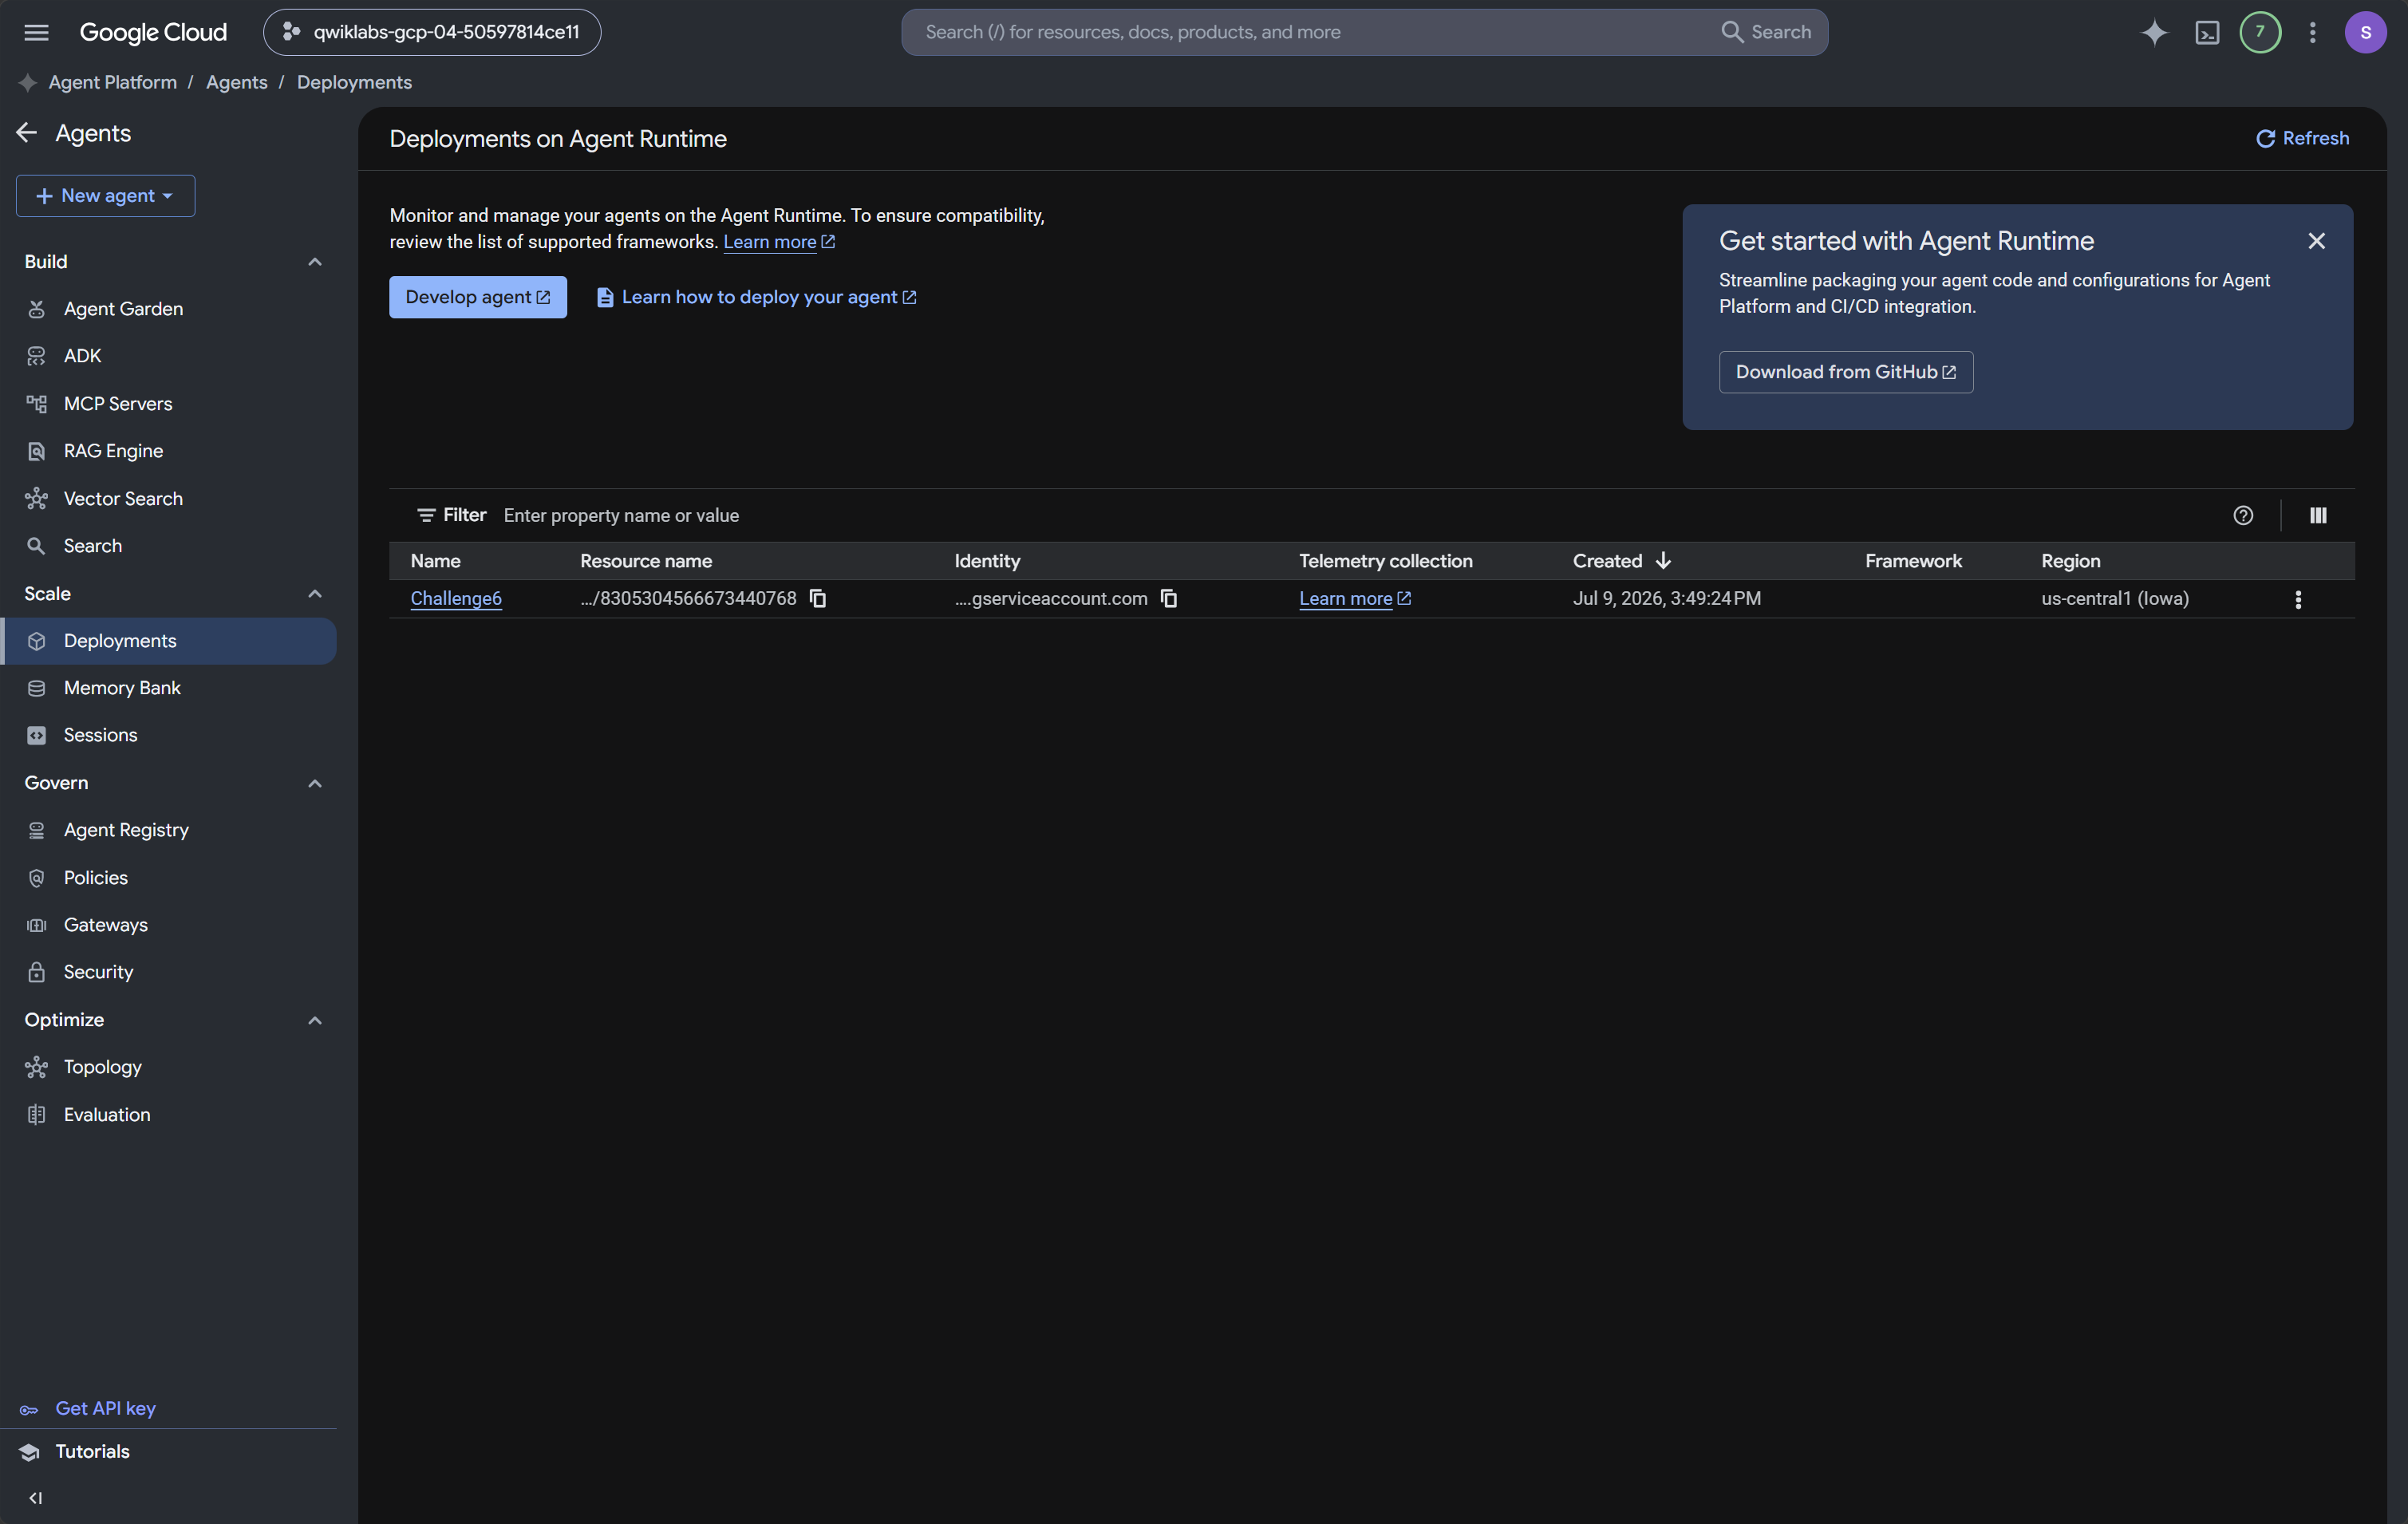